# Presynaptic deployment: held-out test analysis
Six-class pointwise MLP, CAVE n10 pre + post, all five folds. Change `FAMILY` to compare single_pre_post.

All plots load cached held-out **windows** from each saved best checkpoint and its original fold manifest; no training windows or unlabeled deployment data enter this analysis. The original dataset's window deduplication/eligibility rules are preserved. These test splits also selected the best checkpoint, so this is not an independent final test estimate.

Probabilities are **joint probabilities through the hierarchy**. “Selected” means the saved top-down selected class, which need not be the largest joint-probability leaf. Composite plots pool fold predictions, weighted by window count; overlapping folds are not deduplicated.

Caches live on shared storage. Build/refresh: `sbatch analysis/db_deployment/presynaptic/20261009/build_cache.sh`. Existing matching caches are reused. Add `--family single_pre_post` to build the alternative.

In [1]:
%matplotlib inline
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'scripts/train_gnn.py').is_file())
HERE = ROOT / 'analysis/db_deployment/presynaptic/20261009'
sys.path.insert(0, str(HERE))
from cache_analysis import CACHE, SOURCE, digest
from plot_helpers import histograms, probability_lines, accuracy_plot, COLORS
FAMILY = 'cave_n10'  # Or 'single_pre_post'; build that family's cache first.
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
def load_folds(kind):
    paths = [CACHE / FAMILY / f'{kind}_fold{fold}.npz' for fold in range(5)]
    missing = [str(p) for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError('Build cached data with build_cache.sh first. Missing: ' + ', '.join(missing))
    result = []
    for fold, path in enumerate(paths):
        with np.load(path, allow_pickle=False) as z:
            result.append({k: z[k].copy() for k in z.files})
        provenance = json.loads(str(result[-1]['provenance']))
        if kind == 'unlabeled':
            assert provenance['plan_sha256'] == digest(SOURCE / 'plan.json'), 'Stale prediction plan'
        else:
            plan = json.loads((SOURCE / 'plan.json').read_text())
            model = next(m for m in plan['models'] if m['family'] == FAMILY and m['classes'] == 'six' and m['fold'] == fold)
            assert provenance['checkpoint_sha256'] == model['sha256'], 'Stale checkpoint'
            assert provenance['manifest_sha256'] == model['manifest_sha256'], 'Stale split manifest'
    assert all(np.array_equal(z['classes'], result[0]['classes']) for z in result)
    return result

folds = load_folds('test')
classes = folds[0]['classes'].tolist()
selected = [z['probabilities'][np.arange(len(z['prediction'])), z['prediction']] for z in folds]
true_probability = [z['probabilities'][np.arange(len(z['target'])), z['target']] for z in folds]
correct = [z['prediction'] == z['target'] for z in folds]
display(pd.DataFrame({'fold': range(5), 'test_windows': [len(z['target']) for z in folds],
                      'test_roots': [len(np.unique(z['root_id'])) for z in folds],
                      'accuracy': [c.mean() for c in correct]}))

,fold,test_windows,test_roots,accuracy
0,0,293953,359,0.850105
1,1,303352,357,0.876002
2,2,288259,354,0.874856
3,3,297192,353,0.835776
4,4,290232,350,0.879631


## Probability of the selected class

Composite, five-fold overlay, and distributions by **selected (predicted) cell type**, pooled across folds. Each cell-type histogram is independently normalized to unit area.

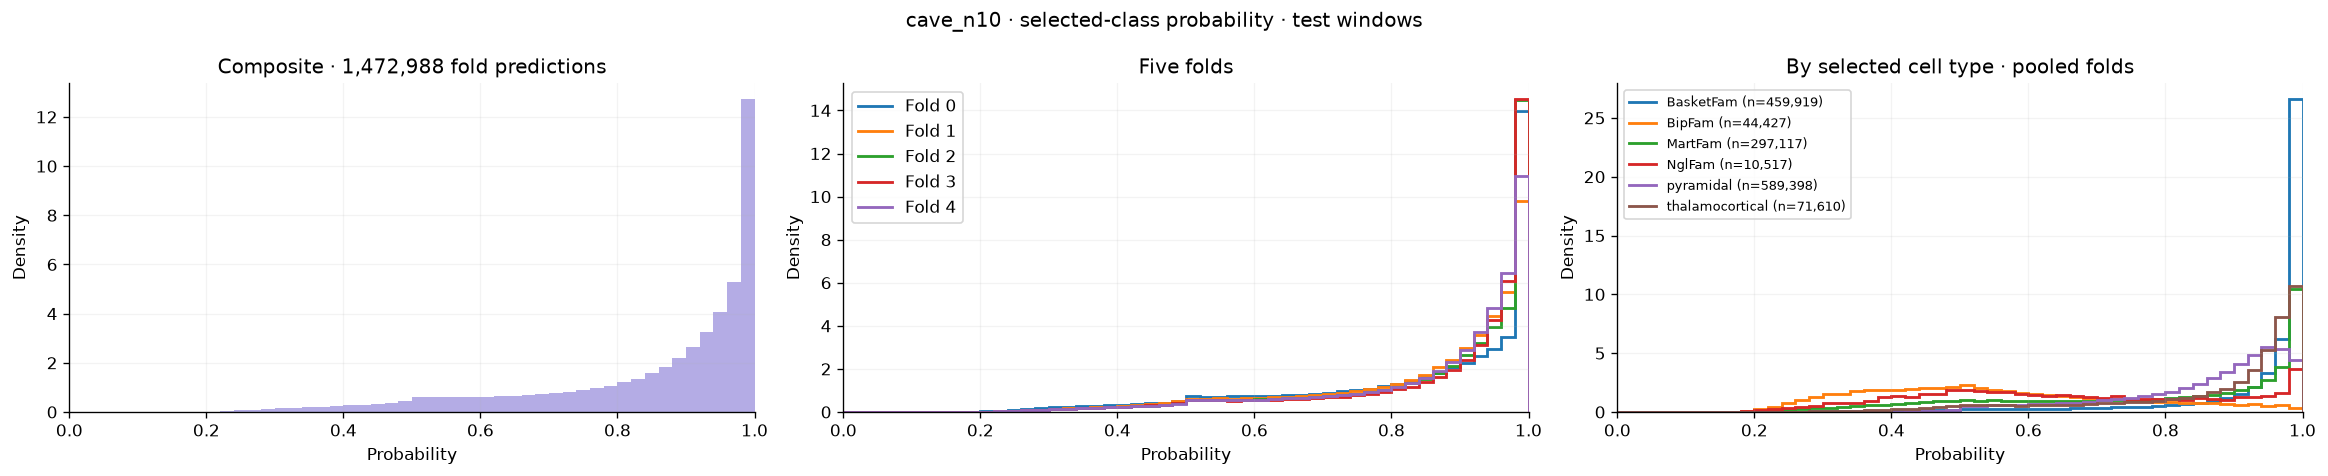

In [2]:
histograms(selected, f'{FAMILY} · selected-class probability · test windows',
           class_ids=[z['prediction'] for z in folds], class_names=classes,
           class_title='By selected cell type · pooled folds')

## Probability of the true class

Composite, five-fold overlay, and distributions by **true cell type**, pooled across folds. Each cell-type histogram is independently normalized to unit area.

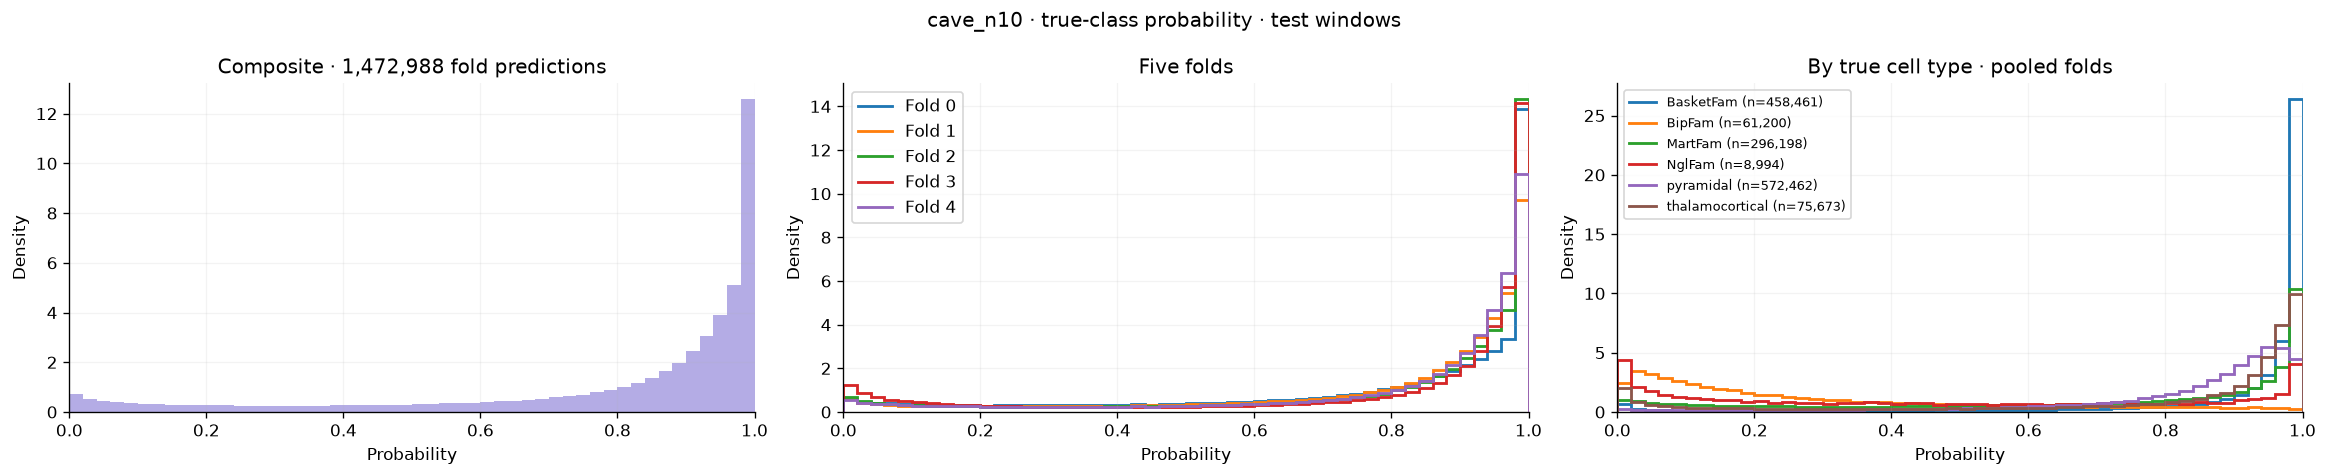

In [3]:
histograms(true_probability, f'{FAMILY} · true-class probability · test windows',
           class_ids=[z['target'] for z in folds], class_names=classes,
           class_title='By true cell type · pooled folds')

## Accuracy as a function of probability
Accuracy is computed **within each probability bin**, including the endpoint 1. Empty bins are gaps. The composite has point-level 95% Wilson intervals; windows sharing a root are correlated. True-class probability is a diagnostic requiring labels, not a deployable confidence threshold.

The third column pools all five folds and shows six class curves: grouped by **selected cell type** for selected-class probability, and by **true cell type** for true-class probability. Each curve measures correctness within its class and probability bin; empty bins remain gaps.

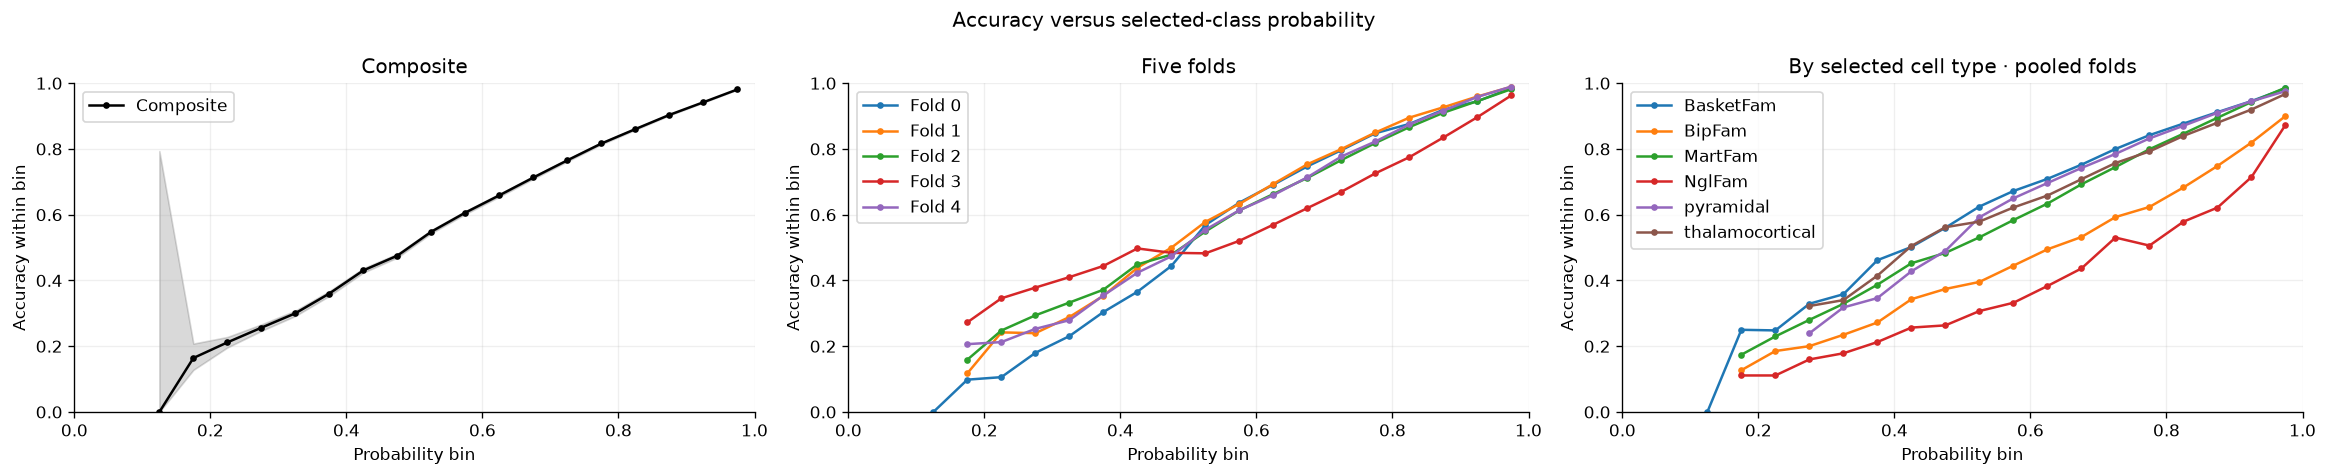

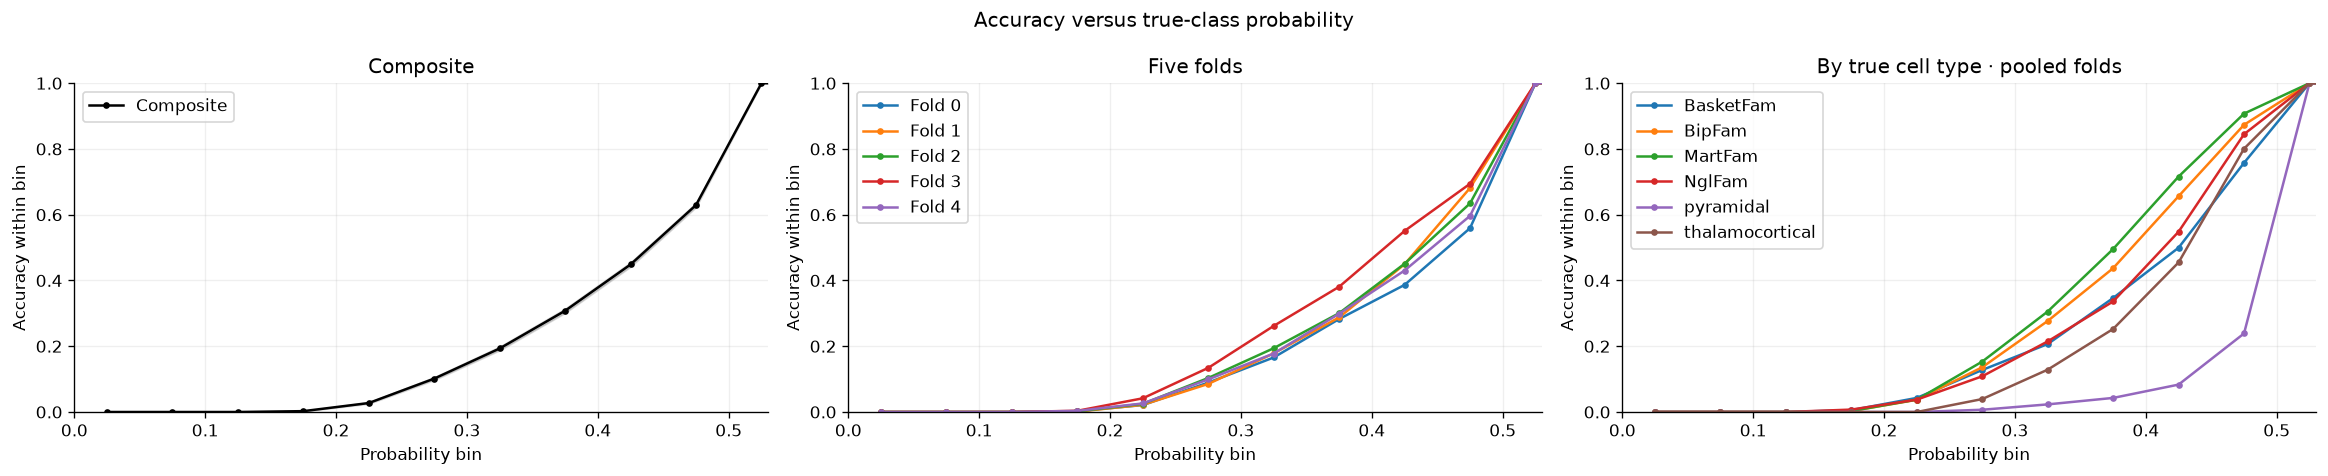

In [4]:
accuracy_plot(selected, correct, 'Accuracy versus selected-class probability',
              class_ids=[z['prediction'] for z in folds], class_names=classes,
              class_title='By selected cell type · pooled folds')
accuracy_plot(true_probability, correct, 'Accuracy versus true-class probability',
              class_ids=[z['target'] for z in folds], class_names=classes,
              class_title='By true cell type · pooled folds', xlim=(0, 0.53))

## Histogram confusion matrix
Rows are true classes and columns are selected classes. Each panel shows raw counts versus probability, pooled over the five test folds. Blue: selected-class probability; orange: true-class probability. The panel count is the ordinary confusion-matrix entry. Axes share probability limits, while y scales vary so rare pairs remain visible.

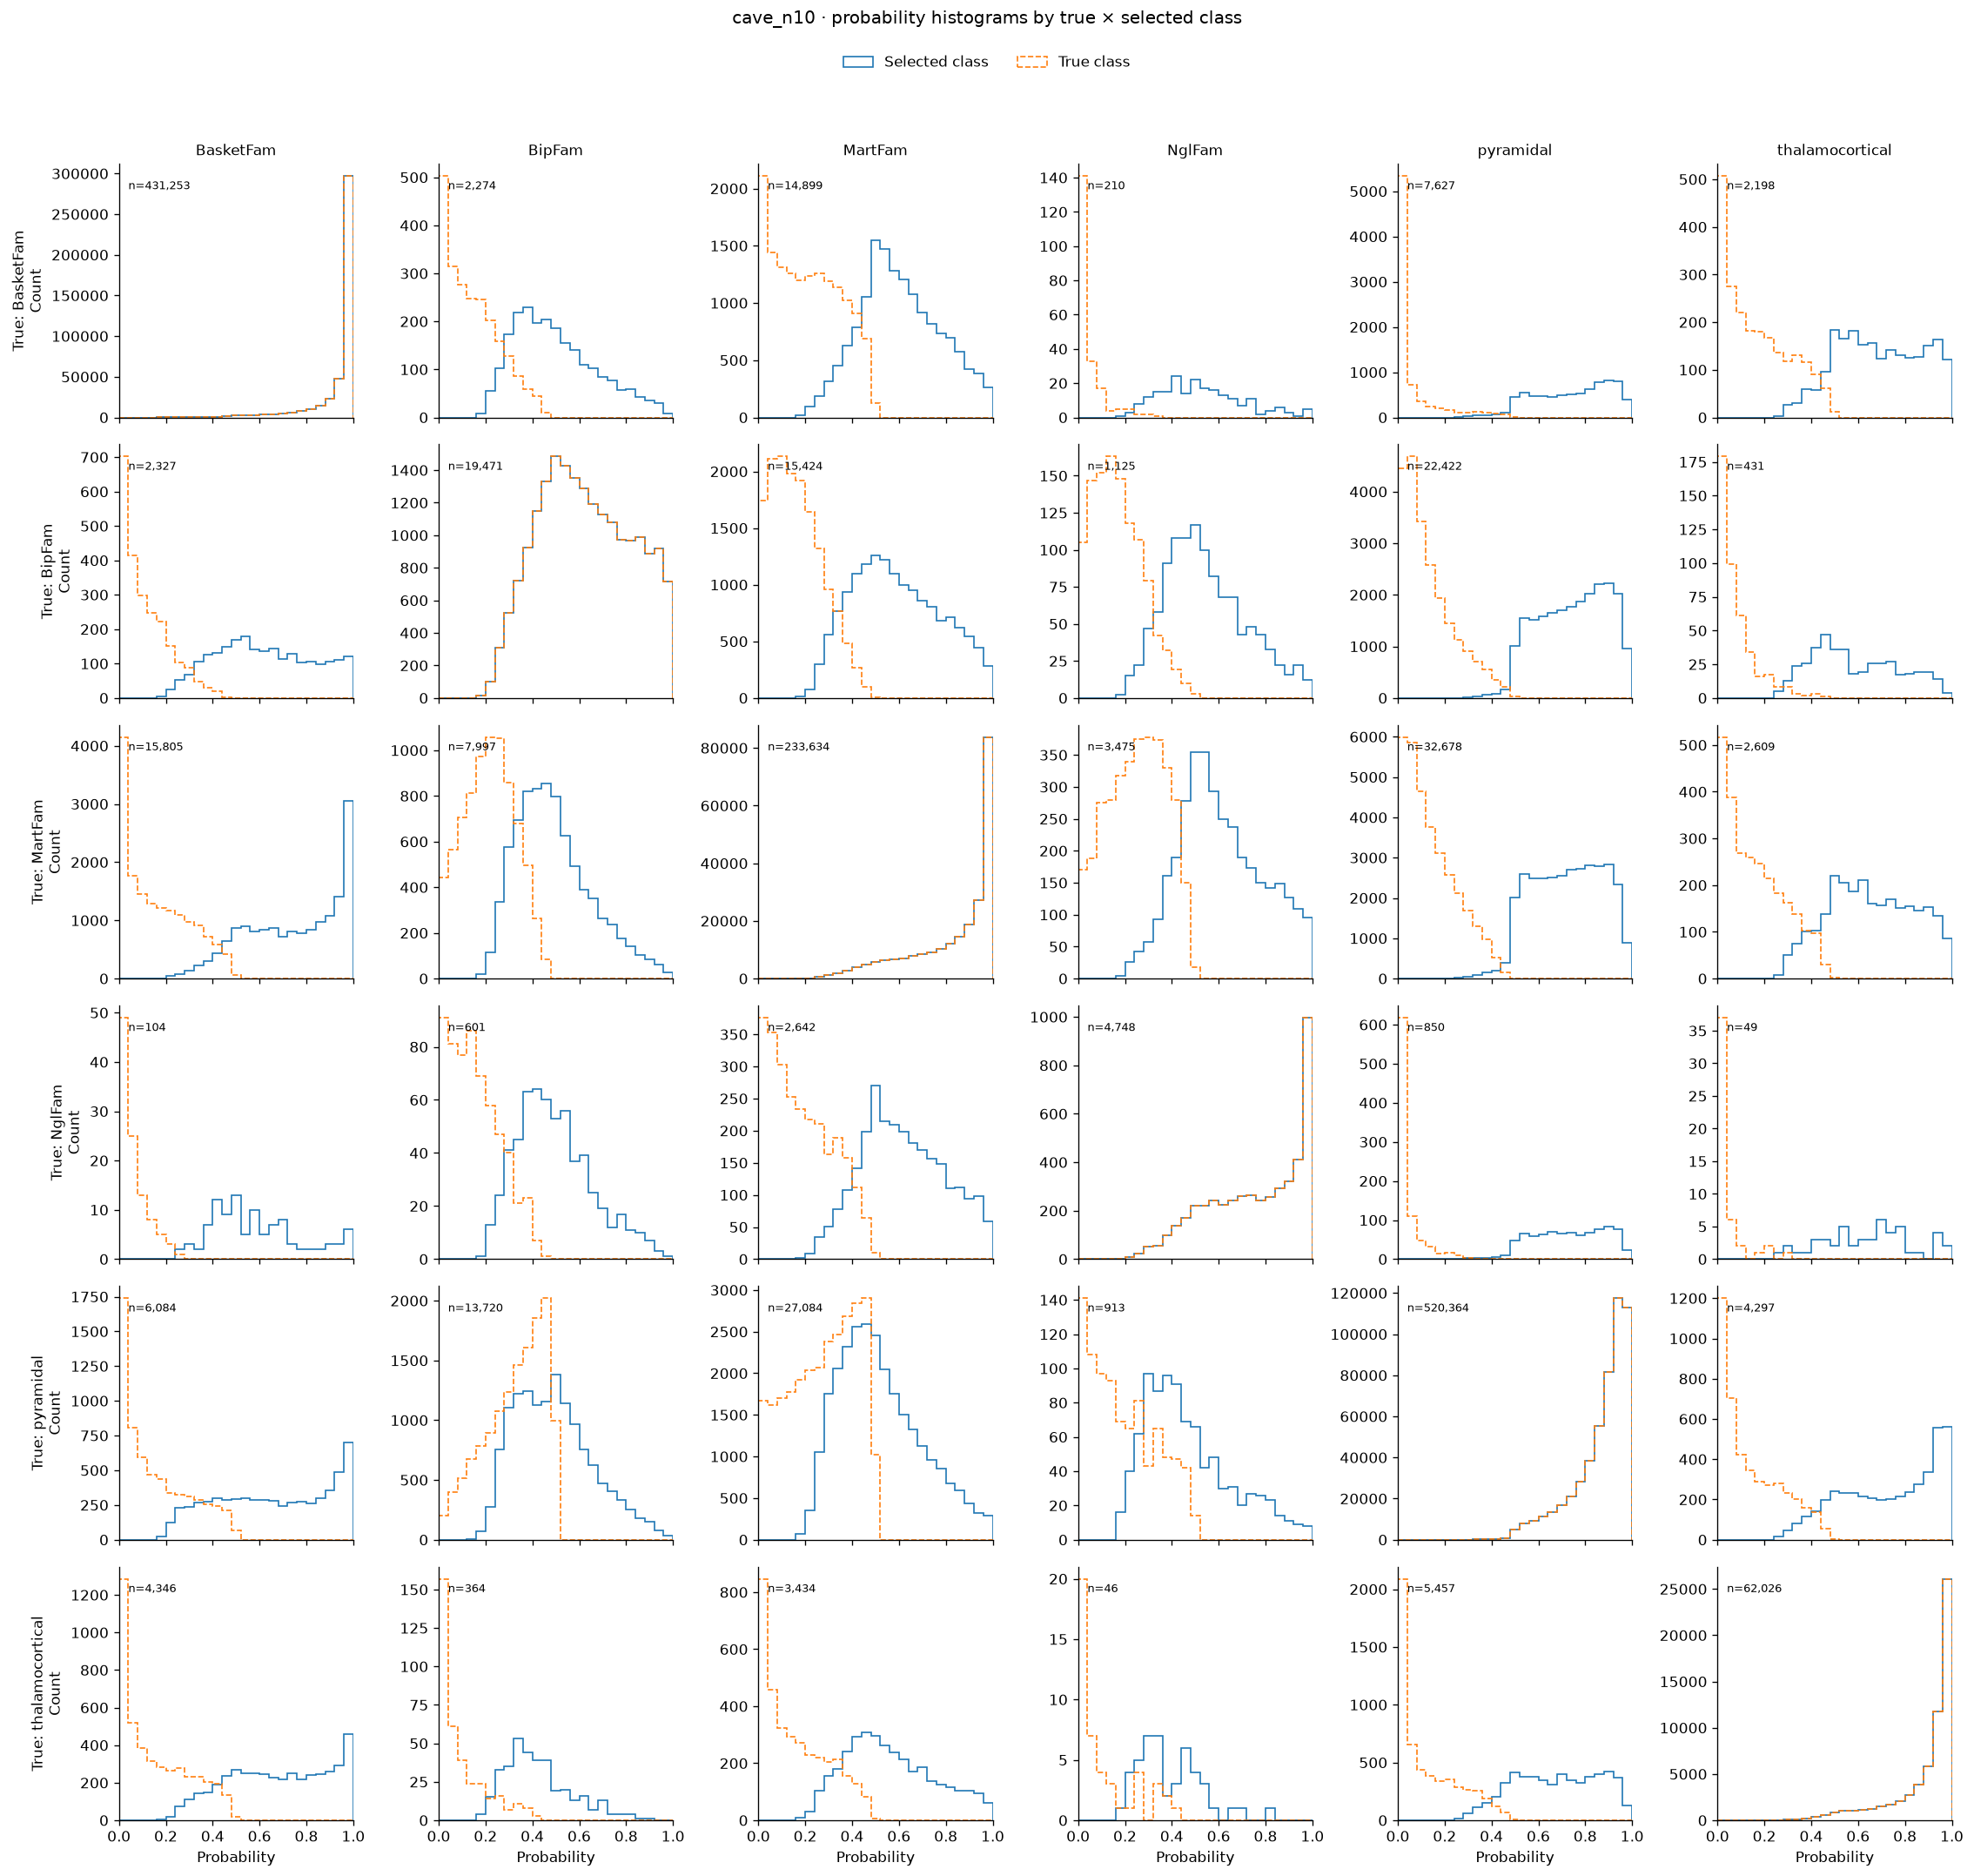

In [5]:
target = np.concatenate([z['target'] for z in folds])
prediction = np.concatenate([z['prediction'] for z in folds])
p_selected, p_true = np.concatenate(selected), np.concatenate(true_probability)
fig, axes = plt.subplots(6, 6, figsize=(19, 18), sharex=True)
bins = np.linspace(0, 1, 26)
for i, truth in enumerate(classes):
    for j, chosen in enumerate(classes):
        ax = axes[i, j]; mask = (target == i) & (prediction == j)
        ax.hist(p_selected[mask], bins=bins, histtype='step', color='tab:blue', label='Selected class')
        ax.hist(p_true[mask], bins=bins, histtype='step', color='tab:orange', linestyle='--', label='True class')
        ax.text(.04, .90, f'n={mask.sum():,}', transform=ax.transAxes, fontsize=8)
        if i == 0: ax.set_title(chosen, fontsize=10)
        if j == 0: ax.set_ylabel(f'True: {truth}\nCount')
        if i == 5: ax.set_xlabel('Probability')
        ax.set_xlim(0, 1)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.suptitle(f'{FAMILY} · probability histograms by true × selected class', y=0.995)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.978),
           ncol=2, frameon=False, fontsize=10)
fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()